In [1]:
import pandas as pd
import numpy as np
import torch as tc
import torch.nn as nn
from scipy.integrate import solve_ivp 

import matplotlib.pyplot as plt
from matplotlib import cm, rc

import time
import pickle

In [44]:
# time span
t_total = 100
t_scale = 1
t_end = 20
t_span = (0/t_scale, t_end/t_scale)           # from 0 to 1
t_eval = np.linspace(0, t_end, t_total)/t_scale

alpha = 0.6; beta = 0.025; delta = 0.0125; gamma = 0.5 

# define first-order system
def lynxhare(t, z):
    x, y = z
    dxdt = alpha*x - beta*x*y
    dydt = delta*x*y - gamma*y
    return [dxdt, dydt]

# solve IVP
x0 = 30; y0 = 4 
sol = solve_ivp(lynxhare, t_span, [x0, y0], t_eval=t_eval)


In [45]:
t_eval = np.linspace(0, t_end, t_total)/t_scale
t_eval = tc.from_numpy(t_eval).float().unsqueeze(1)
x = tc.from_numpy(sol.y[0]).unsqueeze(1).float()
y = tc.from_numpy(sol.y[1]).unsqueeze(1).float()

t_eval /= t_end
##########################################################
sel_end = (x.shape[0])//2 

obs = sel_end//2 + 1 
sel = np.linspace(0, sel_end, obs)
sel = np.int32(sel)

t_data = t_eval[sel]
x_data =  x[sel]
y_data =  y[sel]
all_data = np.hstack([x, y]) 
sel_data = np.hstack([x_data, y_data]) 

all_data = tc.from_numpy(all_data).float()  
sel_data = tc.from_numpy(sel_data).float()  

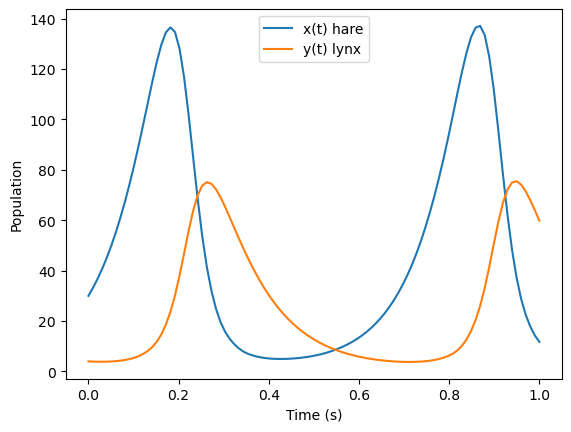

In [46]:
plt.plot(t_eval.detach().numpy(), x.detach().numpy(), label="x(t) hare")
plt.plot(t_eval.detach().numpy(), y.detach().numpy(), label="y(t) lynx")

plt.xlabel("Time (s)")
plt.ylabel("Population")
plt.legend()
plt.show()

In [16]:
class FCNPh(nn.Module):
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.a_train = nn.Parameter(tc.tensor(1.))
        self.b_train = nn.Parameter(tc.tensor(0.01))
        self.c_train = nn.Parameter(tc.tensor(1.))
        self.d_train = nn.Parameter(tc.tensor(0.01))
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x



In [17]:
def plot_result(x, y, x_data, y_data, yh, xp=None, step=None):
    "Pretty plot training results (time-based lynx–hare)"
    
    # convert PyTorch tensors to NumPy arrays if needed
    if isinstance(x, tc.Tensor):
        x = x.detach().cpu().numpy()
    if isinstance(y, tc.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(x_data, tc.Tensor):
        x_data = x_data.detach().cpu().numpy()
    if isinstance(y_data, tc.Tensor):
        y_data = y_data.detach().cpu().numpy()
    if isinstance(yh, tc.Tensor):
        yh = yh.detach().cpu().numpy()
    if xp is not None and isinstance(xp, tc.Tensor):
        xp = xp.detach().cpu().numpy()
    
    plt.figure(figsize=(8,4))
    plt.plot(x, y[:,0], color="grey", linewidth=2, alpha=0.8, label="Hare exact")
    plt.plot(x, y[:,1], color="grey", linewidth=2, alpha=0.8, label="Lynx exact")
    plt.plot(x, yh[:,0], color="tab:blue", linewidth=3, alpha=0.8, label="Hare NN pred")
    plt.plot(x, yh[:,1], color="tab:green", linewidth=3, alpha=0.8, label="Lynx NN pred")
    
    plt.scatter(x_data, y_data[:,0], s=60, color="tab:orange", alpha=0.4, label='Hare training')
    plt.scatter(x_data, y_data[:,1], s=60, color="tab:red", alpha=0.4, label='Lynx training')
    
    if xp is not None:
        plt.scatter(xp, np.zeros_like(xp), s=60, color="tab:purple", alpha=0.4, label='Physics loss locations')
    
    plt.legend(loc="best", frameon=False, fontsize="large")
    
    if step is not None:
        plt.text(0.95, 0.9, f"Training step: {step}", transform=plt.gca().transAxes, fontsize="large")
    
    plt.xlabel("Time (scaled)")
    plt.ylabel("Population")
    plt.show()

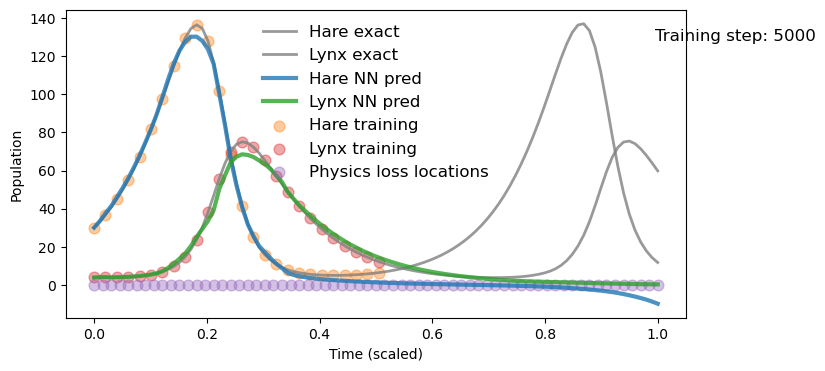

tensor(6.8979, grad_fn=<MeanBackward0>) tensor(3.7565, grad_fn=<MulBackward0>) tensor(0.0214, grad_fn=<MeanBackward0>)
a: tensor(0.5985) b: tensor(0.0271) c: tensor(0.4057) d: tensor(0.0109)


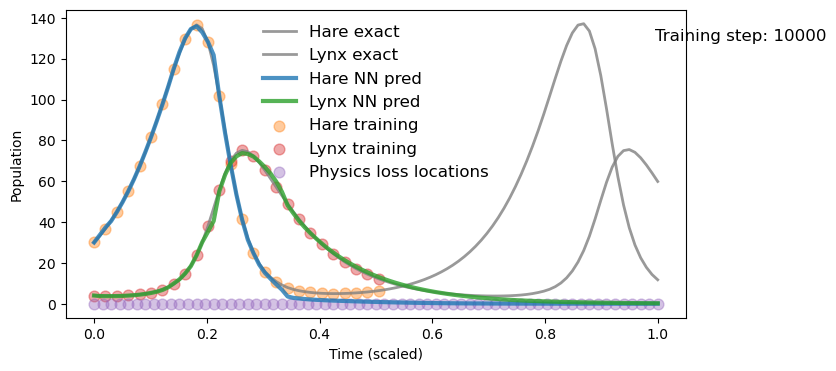

tensor(3.5141, grad_fn=<MeanBackward0>) tensor(1.4503, grad_fn=<MulBackward0>) tensor(5.0285e-06, grad_fn=<MeanBackward0>)
a: tensor(0.6062) b: tensor(0.0264) c: tensor(0.4164) d: tensor(0.0113)


KeyboardInterrupt: 

In [ ]:
num_phy = 67 
x_physics = tc.linspace(0, 1, num_phy).unsqueeze(1).requires_grad_(True)

tc.manual_seed(123)
model = FCNPh(1, 2, 64, 3)

optimizer = tc.optim.Adam(model.parameters(), lr=1e-3)

loss1_list = []; loss2_list = []; loss3_list = []; loss_list=[]

###########################################

for i in range(100000): 
    optimizer.zero_grad()

    a = model.a_train; b = model.b_train; c = model.c_train; d = model.d_train 

    # compute the "data loss"
    pred = model(t_data)
    loss1 = tc.mean((pred - sel_data)**2) 
    # compute the "physics loss"
    phys_pred = model(x_physics)
    x = phys_pred[:, 0]
    y = phys_pred[:, 1]

    f = tc.stack([a*x - b*x*y,
    d*x*y - c*y], dim=1)

    dxdt = tc.autograd.grad(phys_pred[:, 0], x_physics, grad_outputs=tc.ones_like(phys_pred[:, 0]), create_graph=True)[0]
    dydt = tc.autograd.grad(phys_pred[:, 1], x_physics, grad_outputs=tc.ones_like(phys_pred[:, 1]), create_graph=True)[0]

    der = tc.cat([dxdt, dydt], dim=1)
    # dxdt = der[:, 0]
    # dydt = der[:, 1]
    # dxdt = alpha*x - beta*x*y
    # dydt = delta*x*y - gamma*y

    physics = der/t_end - f
    lambdaphy =  1.
    loss2 = lambdaphy * tc.mean(physics**2)
    # print(dx,dx2,loss2,loss1)
    # backpropagate joint loss
    lambdaic = 1. 

    t0 = tc.zeros(1, 1, requires_grad=True)
    y0_pred = model(t0)
    loss3 = tc.mean(lambdaic*((y0_pred - tc.tensor([x0, y0]))**2))

    loss = loss1 + loss2 + loss3 # add three loss terms together
 
    loss1_list.append(loss1.item())
    loss2_list.append(loss2.item())
    loss3_list.append(loss3.item())
    loss_list.append(loss.item())

    loss.backward()
    optimizer.step()
    
    
    # plot the result as training progresses
    if (i+1) % 5000 == 0:
        pred = model(t_eval).detach()
        plot_result(t_eval, all_data, t_data, sel_data, pred, x_physics.detach(), step=i+1)        
        plt.show()   
              
        
        #     file = "plots/pinn_%.8i.png"%(i+1)
        #    plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        #   files.append(file)
        
        print(loss1,loss2,loss3)
        print("a:", a.detach(),"b:", b.detach(), "c:", c.detach(), "d:", d.detach())

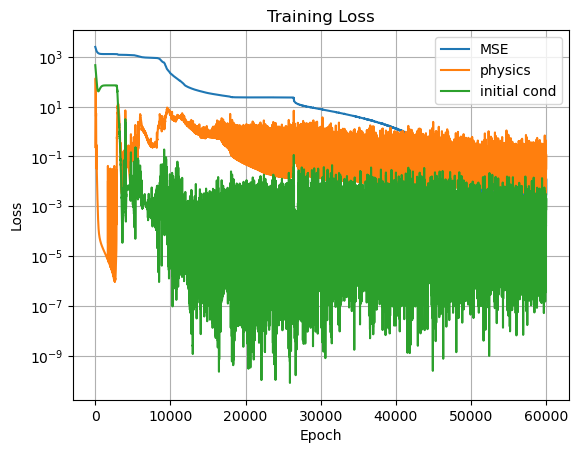

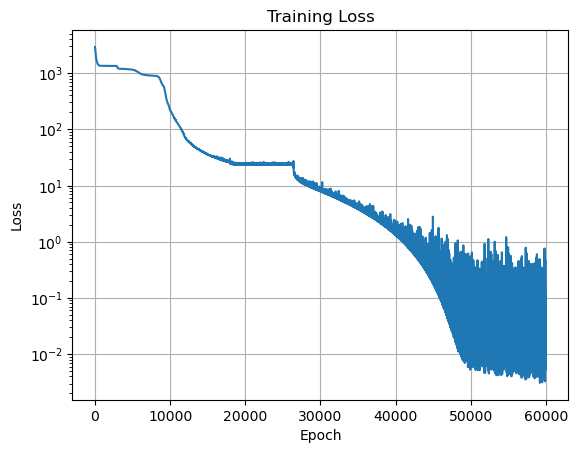

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [24]:
plt.figure()
plt.plot(loss1_list, label="MSE")
plt.plot(loss2_list, label="physics")
plt.plot(loss3_list, label="initial cond")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss")
plt.yscale("log")  # highly recommended for PINNs
plt.grid(True)
plt.show()
plt.figure()
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.yscale("log")  # highly recommended for PINNs
plt.grid(True)
plt.show()
plt.figure()